In [22]:
import duckdb
con = duckdb.connect("econ.duckdb")


In [23]:
con.sql("""CREATE OR REPLACE TABLE gold_quarterly_metrics AS
    SELECT *,
    unemployment_rate - LAG(unemployment_rate) OVER (ORDER BY DATE) AS unemployment_qoq_change,
    inflation_rate - LAG(inflation_rate) OVER (ORDER BY DATE) AS inflation_qoq_change,
    gdp_in_gbp_m - LAG(gdp_in_gbp_m) OVER (ORDER BY DATE) AS gdp_qoq_change,
    trade_balance_gbp_m - LAG(trade_balance_gbp_m) OVER (ORDER BY DATE) AS trade_balance_qoq_change,
    AVG(unemployment_rate) OVER(PARTITION BY year) AS unemployment_yearly_avg,
    AVG(inflation_rate) OVER(PARTITION BY year) AS inflation_yearly_avg,
    AVG(gdp_in_gbp_m) OVER(PARTITION BY year) AS gdp_yearly_avg,
    AVG(trade_balance_gbp_m) OVER(PARTITION BY year) as trade_balance_yearly_avg,
    CASE 
        WHEN (gdp_in_gbp_m - LAG(gdp_in_gbp_m) OVER (ORDER BY date)) < 0
        AND (LAG(gdp_in_gbp_m) OVER (ORDER BY date) - LAG(gdp_in_gbp_m, 2) OVER (ORDER BY date)) < 0
        THEN TRUE 
        ELSE FALSE 
        END AS uk_technical_recession_flag
    FROM silver_quarterly_metrics
""")

In [24]:
con.sql("SELECT * FROM gold_quarterly_metrics")

┌─────────────┬───────┬────────────────┬────────────┬───────────────────┬────────────────┬──────────────┬─────────────────────┬─────────────────────────┬──────────────────────┬────────────────┬──────────────────────────┬─────────────────────────┬──────────────────────┬────────────────┬──────────────────────────┬─────────────────────────────┐
│ quarter_raw │ year  │ quarter_number │    date    │ unemployment_rate │ inflation_rate │ gdp_in_gbp_m │ trade_balance_gbp_m │ unemployment_qoq_change │ inflation_qoq_change │ gdp_qoq_change │ trade_balance_qoq_change │ unemployment_yearly_avg │ inflation_yearly_avg │ gdp_yearly_avg │ trade_balance_yearly_avg │ uk_technical_recession_flag │
│   varchar   │ int32 │     int32      │    date    │      double       │     double     │    double    │       double        │         double          │        double        │     double     │          double          │         double          │        double        │     double     │          double          

In [29]:
gold_df = con.sql("SELECT * FROM gold_quarterly_metrics").df()
display(gold_df)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

,quarter_raw,year,quarter_number,date,unemployment_rate,inflation_rate,gdp_in_gbp_m,trade_balance_gbp_m,unemployment_qoq_change,inflation_qoq_change,gdp_qoq_change,trade_balance_qoq_change,unemployment_yearly_avg,inflation_yearly_avg,gdp_yearly_avg,trade_balance_yearly_avg,uk_technical_recession_flag
0,2017 Q1,2017,1,2017-01-01,4.6,2.1,642463.0,-5949.0,-0.1,0.9,6071.0,-333.0,4.425,2.650,649990.25,-6513.25,False
1,2017 Q2,2017,2,2017-04-01,4.4,2.7,647944.0,-7517.0,-0.2,0.6,5481.0,-1568.0,4.425,2.650,649990.25,-6513.25,False
2,2017 Q3,2017,3,2017-07-01,4.3,2.8,652329.0,-6619.0,-0.1,0.1,4385.0,898.0,4.425,2.650,649990.25,-6513.25,False
3,2017 Q4,2017,4,2017-10-01,4.4,3.0,657225.0,-5968.0,0.1,0.2,4896.0,651.0,4.425,2.650,649990.25,-6513.25,False
4,2022 Q1,2022,1,2022-01-01,3.8,6.2,682527.0,-25395.0,-0.4,1.3,6847.0,-25775.0,3.800,9.025,686177.00,-6936.75,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,2003 Q4,2003,4,2003-10-01,4.9,1.3,528320.0,-7498.0,-0.1,-0.1,4107.0,-284.0,5.000,1.375,521341.50,-6725.25,False
114,2016 Q1,2016,1,2016-01-01,5.1,0.3,625099.0,-7379.0,0.0,0.2,3131.0,-836.0,4.875,0.650,630916.25,-8602.50,False
115,2016 Q2,2016,2,2016-04-01,4.9,0.4,629697.0,-5483.0,-0.2,0.1,4598.0,1896.0,4.875,0.650,630916.25,-8602.50,False
116,2016 Q3,2016,3,2016-07-01,4.8,0.7,632477.0,-15932.0,-0.1,0.3,2780.0,-10449.0,4.875,0.650,630916.25,-8602.50,False


Text(0, 0.5, 'Unemployment Rate(%)')

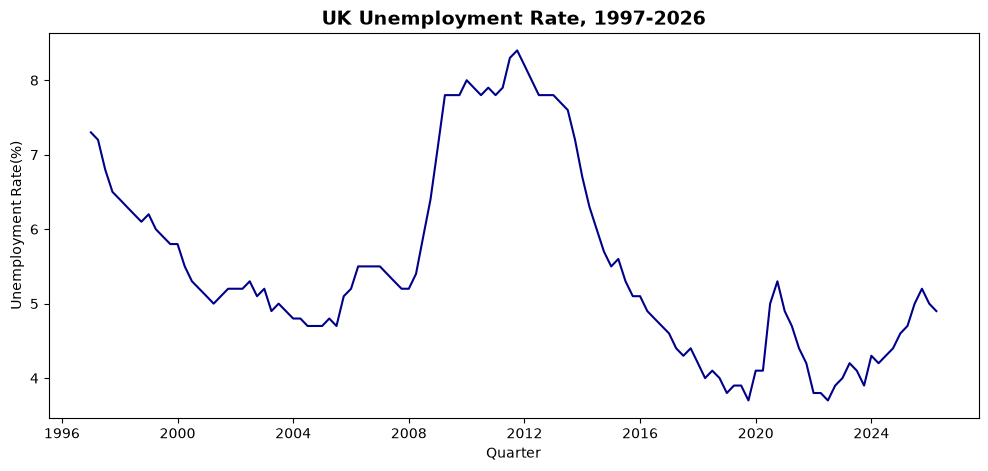

In [42]:
plt.figure(figsize=(12,5))
sns.lineplot(data=gold_df, x= 'date', y='unemployment_rate', color='darkblue')
plt.title('UK Unemployment Rate, 1997-2026', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Unemployment Rate(%)')

Text(0, 0.5, '£ Millions')

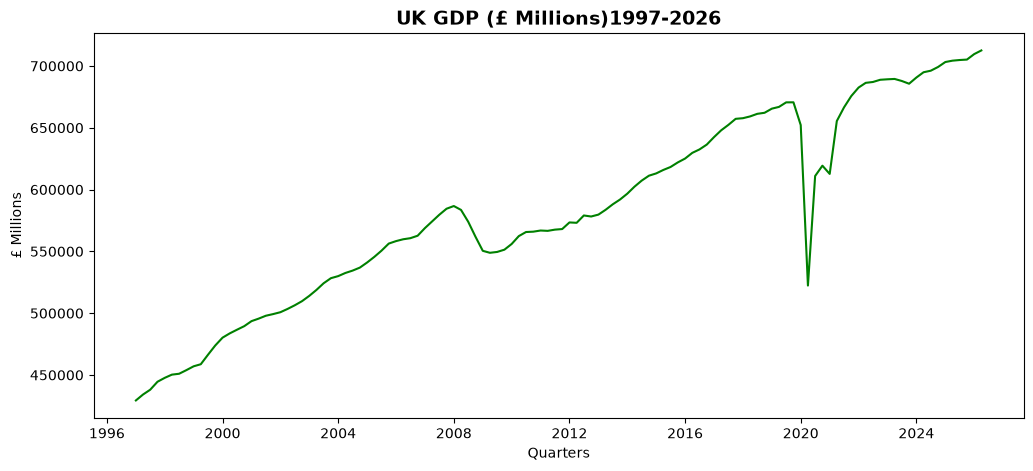

In [51]:
plt.figure(figsize=(12,5))
sns.lineplot(data=gold_df, x='date', y='gdp_in_gbp_m', color='green')
plt.title('UK GDP (£ Millions)1997-2026', fontsize=14, fontweight='bold')
plt.xlabel('Quarters')
plt.ylabel('£ Millions')